In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats

# Problem 1
Consider a causal system given by the following system function
$$
H(z) = 1 + 3.5z^{-1} + 1.5z^{-2}
$$
and assume that the causal system is used as a model for a communication channel that
will distort signals passing through it.

## 1. Design an equalizer that can mitigate the distortion.

To design an equalizer we first have to determine what kind of system we are dealing with by analyzing the zeros of the system. We can factor the system function as follows:
\begin{align*}
H(z) &= 1 - ((-3)+(-0.5))z^{-1} + (-3)(-0.5)z^{-2}\\
&= (1 - (-3)z^{-1}) (1 - (-0.5)z^{-1})\\
&= (1 + 3z^{-1}) (1 + 0.5z^{-1})
\end{align*}

In this form it can be seen that there is a zero at $z = -3$ and $z = -0.5$. The zero at $z = -3$ is outside the unit circle meaning that it is a mixed-phase system. An equalizer is the inverse of the system but inverting any nonminimum-phase system will result in an unstable system. To avoid this we have to reflect the zero outside the unit circle inside the unit circle. To not affect the magnitude response during inversino, we have to find a corresponding all-pass system that cancels out the effect on the magnitude response. This is done using equation (5.174) as follows:
\begin{align*}
H(z) &= 3 \left( z^{-1} + \frac{1}{3} \right) (1 + 0.5z^{-1})\\
&= 3 \left( z^{-1} + \frac{1}{3} \right) (1 + 0.5z^{-1}) \frac{1 + \frac{1}{3}z^{-1}}{1 + \frac{1}{3} z^{-1}}\\
&=  \underbrace{3\left( 1 + \frac{1}{3} z^{-1} \right) (1 + 0.5z^{-1})}_{H_{\min}(z)} \underbrace{\frac{z^{-1} + \frac{1}{3}}{1 + \frac{1}{3} z^{-1}}}_{H_{\text{ap}}(z)}
\end{align*}

This decomposition yields a minimum phase system that can be inverted to get the equalizer following equation (5.187). The all-pass system part is not relevant since it has a magnitude response of 1.
\begin{align*}
H_{eq}(z) &= \frac{1}{H_{\min}(z)}\\
&= \frac{1}{3\left( 1 + \frac{1}{3} z^{-1} \right) (1 + 0.5z^{-1})}\\
&= \frac{1}{(3 + 1z^{-1})(1 + 0.5z^{-1})}\\
&= \frac{1}{3 + 1.5z^{-1} + 1z^{-1} + 0.5z^{-2}}\\
&= \frac{1}{3 + 2.5z^{-1} + 0.5z^{-2}}
\end{align*}

## 2. Make a time-domain simulation of the system and the equalizer using a test signal of your choice. Explain the choice of test signal and procedures, present plots, and analyze the performance of the equalizer.

The system and equalizer are simulated using a chirp signal from 20Hz to 20kHz since it represents the frequency range of human hearing fitting perfectly to the usecase of a communication channel. The chirp signal is passed through the system and then the equalizer to see how well it cancels out the distortion.

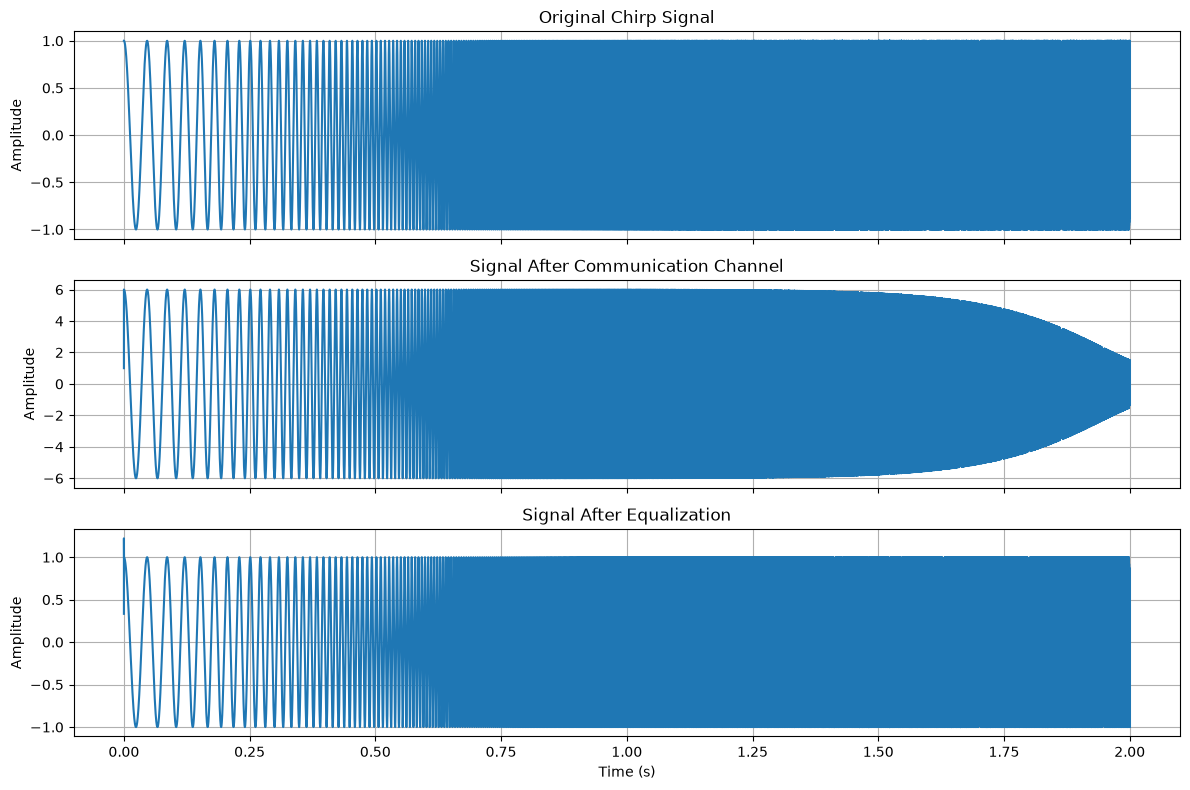

In [2]:
fs = 50000      # sampled at well over the nyquist frequenct of 40kHz
duration = 2

t = np.arange(0, duration, 1/fs)
x = signal.chirp(t, f0=20, f1=20000, t1=duration, method='logarithmic')

h_num = [1, 3.5, 1.5]
h_den = [1]
y = signal.lfilter(h_num, h_den, x)

h_eq_num = [1]
h_eq_den = [3, 2.5, 0.5]
y_eq = signal.lfilter(h_eq_num, h_eq_den, y)

plt.subplots(3, 1, figsize=(12, 8), sharex=True)
plt.subplot(3, 1, 1)
plt.plot(t, x)
plt.title("Original Chirp Signal")
plt.ylabel("Amplitude")
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(t, y)
plt.title("Signal After Communication Channel")
plt.ylabel("Amplitude")
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(t, y_eq)
plt.title("Signal After Equalization")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()

plt.tight_layout()
plt.show()

It can be seen that the communication channel distorts the signal by amplifying only the low frequencies and rolls off the amplification until it has a minimum gain of around 0dB at 20kHz. The equalizer is then able to cancel out the gain distortion and restore the sample back to an amplitude of 1. The equalization however has some distortion in the start of the signal, which can be analyzed further.

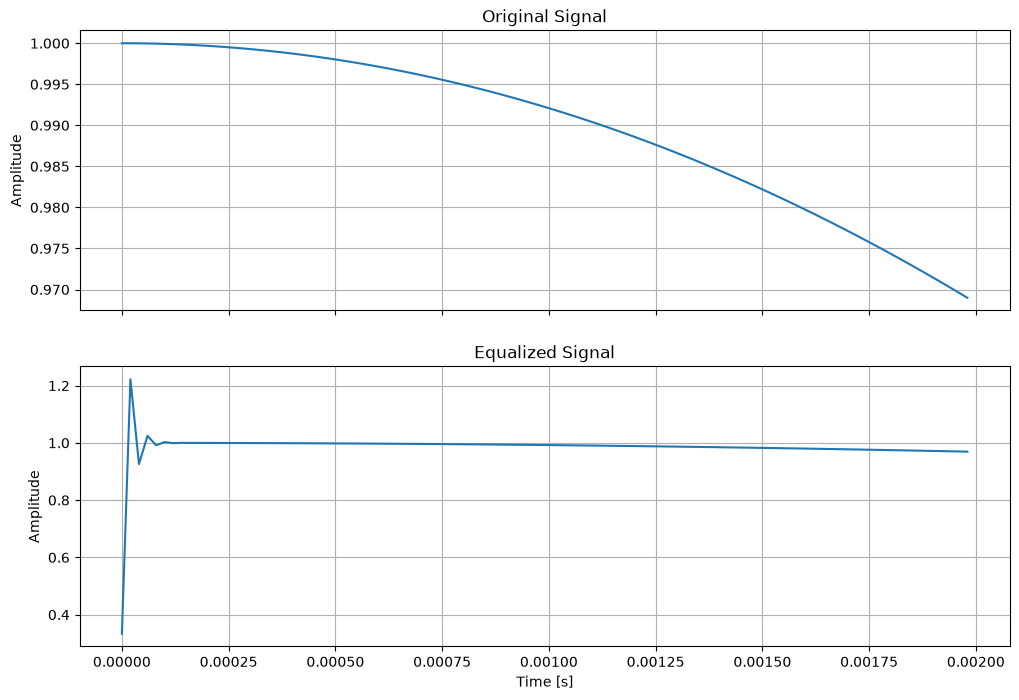

In [3]:
plt.subplots(2, 1, figsize=(12, 8), sharex=True)
plt.subplot(2, 1, 1)
plt.plot(t[:100], x[:100])
plt.title("Original Signal")
plt.ylabel("Amplitude")
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(t[:100], y_eq[:100])
plt.title("Equalized Signal")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

Looking at the distortion closer up it seems to be a transient overshoot. This is likely due to the fact that the equalizer is an IIR filter.

## 3. Next, assume that after the signal has passed through the communication channel is it further distorted by additive white Gaussian noise before it enters the equalizer designed above. How are the results affected by the additive noise?

The white Gaussian noise ($w[n]$) is essentially added between the communication channel and the equalizer. This means that the equalizer will filter both signal and noise giving:
$$
y_{eq}[n] = H_{eq}(z) \left( H(z)x[n] + w[n] \right) = x[n] + H_{eq}(z)w[n]
$$

Since the communication channel was a low-pass filter, the equalizer can be seen as a high-pass filter. This means that the equalizer will essentially amplify the high frequency noise and the output will be distorted, meaning that it can no longer recreate the original signal that well. This can also be shown in the time-domain simulation with the same test signal from before:

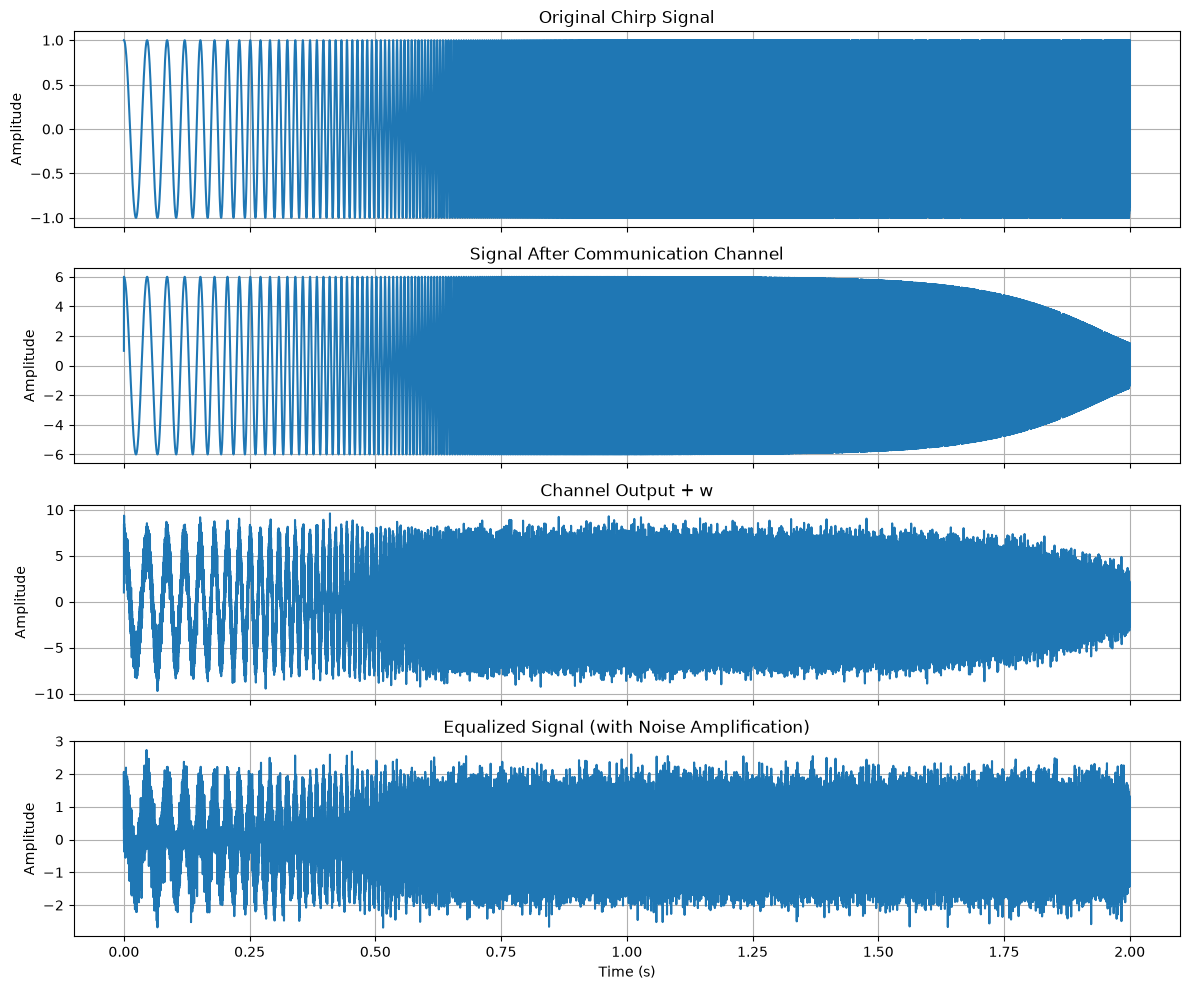

In [4]:
w = np.random.normal(0, 1, len(x)) # unit variance white Gaussian noise

y_noisy = y + w
y_eq = signal.lfilter(h_eq_num, h_eq_den, y_noisy)

plt.subplots(4, 1, figsize=(12, 10), sharex=True)
plt.subplot(4, 1, 1)
plt.plot(t, x)
plt.title("Original Chirp Signal")
plt.ylabel("Amplitude")
plt.grid()

plt.subplot(4, 1, 2)
plt.plot(t, y)
plt.title("Signal After Communication Channel")
plt.ylabel("Amplitude")
plt.grid()

plt.subplot(4, 1, 3)
plt.plot(t, y_noisy)
plt.title(f"Channel Output + w")
plt.ylabel("Amplitude")
plt.grid()

plt.subplot(4, 1, 4)
plt.plot(t, y_eq)
plt.title("Equalized Signal (with Noise Amplification)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()

plt.tight_layout()
plt.show()

# Problem 2
Consider the random process $x[n]$ created as $x[n] = 4w[n] − 2w[n − 3]$ where $w[n]$ is unit
variance white Gaussian noise.

## 1. Compute an analytic expression for the autocorrelation $r_{xx}[l]$.

Since the process is a linear combination of white Gaussian noise, assuming it is also zero mean, the autocorrelation can be computed as follows:
\begin{align*}
r_{xx}[l] &= E(x[n]x[n-l])\\
&= E((4w[n] - 2w[n - 3])(4w[n - l] - 2w[(n - l) - 3]))\\
&= E(16w[n]w[n - l] - 8w[n]w[n - l - 3] - 8w[n - 3]w[n - l] + 4w[n - 3]w[n - l - 3])\\
&= 16E(w[n]w[n - l]) - 8E(w[n]w[n - l - 3]) - 8E(w[n - 3]w[n - l]) + 4E(w[n - 3]w[n - l - 3])
\end{align*}

An expected values of the form $E[w[n]w[n - l]]$ equates to the autocorrelation of the white Gaussian noise $r_{ww}[l]$, again assuming that we are working with zero mean Gaussian noise. Only one of the terms follow this exact form, the others have additional time lag. Since the autocorrelation depends on lag the relative lag for each term can be computed and then set as the input for $r_{ww}[l]$. The lag for each term can be computed as follows:

$$
n - (n - l) = l
$$
$$
n - (n - l - 3) = l + 3
$$
$$
n - 3 - (n - l) = l - 3
$$
$$
n - 3 - (n - l - 3) = l
$$

$r_{ww}[l]$ can then inserted into the equation above along with these lags. Given that $w[n]$ has unit variance, $\sigma^2 = 1$, the autocorrelation, $r_{ww}[l]$, can be substituted by $\delta[l]$.

\begin{align*}
r_{xx}[l] &= 16r_{ww}[l] - 8r_{ww}[l+3] - 8r_{ww}[l-3] + 4r_{ww}[l]\\
&= 16\delta[l] - 8\delta[l+3] - 8\delta[l-3] + 4\delta[l]\\
&= 20\delta[l] - 8\delta[l+3] - 8\delta[l-3]
\end{align*}

## 2. Plot the power spectral density of the random process. What can be learned from the plot?

The power spectral density is found as the Fourier transform of the ACRS following equation (13.112):
\begin{align*}
S_{xx}(\omega) &= \sum_{l = -\infty}^{\infty} r_{xx}[l] e^{ -jl\omega }\\
&= 20 e^{ j 0 \omega} - 8 e^{ j 3 \omega} - 8 e^{ j (-3) \omega}\\
&= 20 - 8e^{ j (3 \omega) } - 8e^{ -j (3\omega) }\\
&= 20 - 8 \left( e^{ j (3 \omega) } + e^{ -j (3\omega) } \right)\\
&= 20 - 8 \left( 2\cos(3\omega) \right)\\
&= 20 - 16\cos(3\omega)
\end{align*}

It can then be plotted using using python.

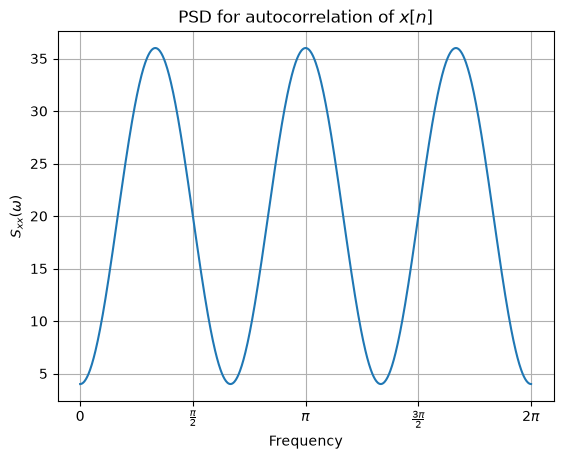

In [5]:
omega = np.linspace(0, 2*np.pi, 1000)
S_xx = 20 - 16 * np.cos(3 * omega)
plt.plot(omega, S_xx)
plt.title('PSD for autocorrelation of $x[n]$')
plt.xlabel('Frequency')
plt.ylabel('$S_{xx}(\\omega)$')
plt.grid()
ticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
labels = ['$0$', '$\\frac{\\pi}{2}$', '$\\pi$', '$\\frac{3\\pi}{2}$', '$2\\pi$']
plt.xticks(ticks, labels)
plt.show()

Unlike the PSD of white noise, the plot shows that the signal's power is amplified at periodic frequencies. These frequencies correspond to when the cosine term in $S_{xx}(\omega)$ is equal to -1, which occurs at $\omega = \frac{(2k + 1)\pi}{3}$ where $k \in \mathbb{Z}$. At these peaks, the signal's power is amplified to 36, while at the troughs occuring at $\omega = \frac{2k\pi}{3}$, the signal's power is reduced to 4.

## 3. Assume $x[n]$ is filtered through a FIR filter with $H(z) = 5 + z^{−1}$. Compute the analytic expressions for $r_{yx}[l]$ and $r_{yy}[l]$

The FIR filter can be expressed in the time domain as follows:
$$
h[n] = 5\delta[n] + \delta[n-1]
$$

Since it is only made up of scalar multiplication and time shifting it is a LTI system. The cross-correlation can then be computed with equation (13.100) as follows:
\begin{align*}
r_{yx}[l] &= h[l] * r_{xx}[l]\\
&= 5r_{xx}[l] + r_{xx}[l-1]\\
&= 5 \cdot (20\delta[l] - 8\delta[l+3] - 8\delta[l-3]) + 20\delta[l - 1] - 8\delta[(l - 1) + 3] - 8\delta[(l - 1) - 3]\\
&= 100\delta[l] - 40\delta[l + 3] - 40 \delta[l - 3] + 20\delta[l - 1] - 8\delta[l + 2] - 8 \delta[l - 4]
\end{align*}

The autocorrelation of $y[n]$ can then be calculated using equation (13.104). To do that the autocorrelation of the filter first has to be computed with equation (13.103):
\begin{align*}
r_{hh}[m] &= h[-m] * h[m]\\
&= 5h[m] + h[m + 1]\\
&= 5 \cdot (5\delta[m] + \delta[m - 1]) + 5\delta[m + 1] + \delta[(m + 1) - 1]\\
&= 25\delta[m] + 5\delta[m - 1] + 5\delta[m + 1] + \delta[m]\\
&= 26\delta[m] + 5\delta[m - 1] + 5\delta[m + 1]
\end{align*}

This can then be inserted alongside $r_{xx}[l]$ into equation (13.104) to get the autocorrelation of $y[n]$:
\begin{align*}
r_{yy}[l] &= r_{hh}[l] * r_{xx}[l]\\
&= 26r_{xx}[l] + 5r_{xx}[l - 1] + 5r_{xx}[l + 1]\\
&= 26 \cdot (20\delta[l] - 8\delta[l+3] - 8\delta[l-3]) + \\
&\quad 5 \cdot (20\delta[(l-1)] - 8\delta[(l-1)+3] - 8\delta[(l-1)-3]) + \\
&\quad 5 \cdot (20\delta[(l+1)] - 8\delta[(l+1)+3] - 8\delta[(l+1)-3])\\
&= 520\delta[l] - 208\delta[l+3] - 208\delta[l-3] + 100\delta[l-1] - \\
&\quad 40\delta[l+2] - 40\delta[l-4] + 100\delta[l+1] - 40\delta[l+4] - 40\delta[l-2]
\end{align*}

Which can also be expressed as follows:
$$
r_{yy}[l] =
\begin{cases}
520 & l=0 \\
100 & l=\pm 1 \\
-40 & l=\pm 2, \pm 4 \\
-208 & l=\pm 3 \\
0 & \text{elsewhere}
\end{cases}
$$

# Problem 3
Let a signal and interpolation kernel be given by
$$
x[n] = 
\begin{cases}
2 & n = 0\\
1 & n = 1\\
0, & \text{elsewhere}
\end{cases}
\quad \text{ and } \quad
g[n] = 
\begin{cases}
-1 & n = -1\\
3 & n = 0\\
-1 & n = 1\\
0 & \text{elsewhere}
\end{cases}
$$

## 1. Upsample $x[n]$ by a factor of 3 and sketch the upsampled signal.

Upsampling by a factor of 3 means that we insert 2 zeros between each of the samples of $x[n]$ resulting in the following signal:
$$
x_{\text{u}}[n] =
\begin{cases}
2 & n = 0\\
1 & n = 3\\
0 & \text{elsewhere}
\end{cases}
$$

This can be plotted using python

Text(0, 0.5, '$x_{\\text{u}}[n]$')

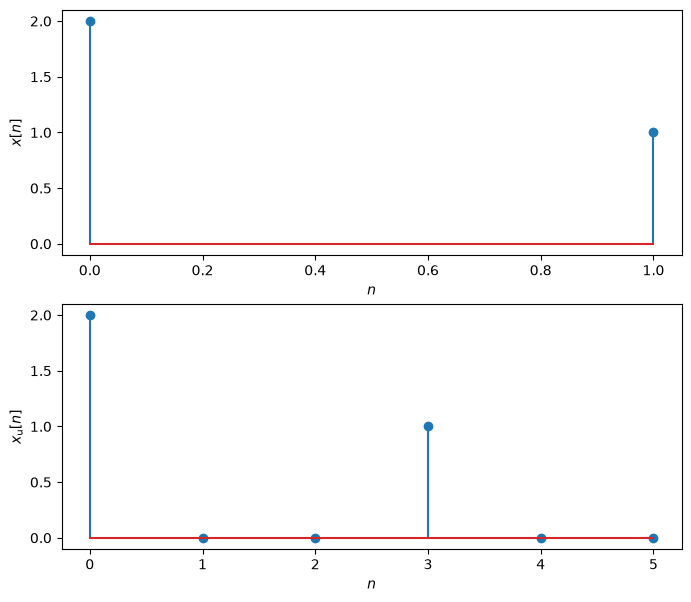

In [6]:
n = np.arange(0, 2, 1)
x = [2, 1]
plt.subplots(2, 1, figsize=(8, 7))
plt.subplot(2, 1, 1)
plt.stem(n, x)
plt.xlabel('$n$')
plt.ylabel('$x[n]$')

n_u = np.arange(0, 6, 1)
x_u = [2, 0, 0, 1, 0, 0]
plt.subplot(2, 1, 2)
plt.stem(n_u, x_u)
plt.xlabel('$n$')
plt.ylabel('$x_{\\text{u}}[n]$')

## 2. Compute the interpolated values $x_I[1]$ and $x_I[2]$ using first linear interpolation and second the proposed $g[n]$ kernel.

Using the linear interpolation definition in equation (12.47a):
$$
x_I[(m - 1)I + k] = x[m - 1] + (x[m] - x[m - 1]) \frac{k}{I}
$$

Given that there is only one interval to be interpolated $m$ in the equation can be set to 1 and the equation can be evaluated for each value of $k$.

For $k = 0$:
\begin{align*}
x_{I}[(1 - 1) \cdot 3 + 0] &= x[1 - 1] + (x[1] - x[1 - 1]) \frac{0}{3}\\
x_{I}[0] &= x[0] + 0\\
&= 2
\end{align*}

For $k = 1$:
\begin{align*}
x_{I}[(1 - 1) \cdot 3 + 1] &= x[1 - 1] + (x[1] - x[1 - 1]) \frac{1}{3}\\
x_{I}[1] &= 2 + (1 - 2)\frac{1}{3}\\
&= \frac{5}{3}
\end{align*}

For $k = 2$:
\begin{align*}
x_{I}[(1 - 1) \cdot 3 + 2] &= x[1 - 1] + (x[1] - x[1 - 1]) \frac{2}{3}\\
x_{I}[2] &= 2 + (1 - 2)\frac{2}{3}\\
&= \frac{4}{3}
\end{align*}

The proposed kernel can be used to interpolate x[n] by convolving it with the upsampled signal. To make it convolution easier to write out, the upsampled signal and kernel can be expressed in terms of delta functions as follows:
$$
x_{\text{u}}[n] = 2\delta[n] + \delta[n - 3]
$$
$$
g[n] = -\delta[n + 1] + 3\delta[n] - \delta[n - 1]
$$

The convolution will then be
\begin{align*}
x_{I}[n] &= g[n] * x_{\text{u}}[n]\\
&= -x_{\text{u}}[n + 1] + 3x_{\text{u}}[n] - x_{\text{u}}[n - 1]\\
&= -(2\delta[n+1] + \delta[(n+1) - 3]) + 3 \cdot (2\delta[n] + \delta[n - 3]) - (2\delta[n-1] + \delta[(n-1) - 3])\\
&= -2\delta[n+1] - \delta[n-2] + 6\delta[n] + 3\delta[n-3] - 2\delta[n-1] - \delta[n-4]\\
\end{align*}

This can be expressed as
$$
x_{I}[n] =
\begin{cases}
-2 & n = \pm 1\\
6 & n = 0\\
-1 & n = 2, 4\\
3 & n = 3\\
0 & \text{elsewhere}
\end{cases}
$$

meaning that the interpolated values using the suggested proposed kernel are $x_{I}[1] = -2$ and $x_{I}[2] = -1$.

## 3. Discuss the performance of the $g[n]$ interpolation kernel relative to ideal and linear interpolation.

Looking at the original samples in the interpolated signal at $n = 0$ and $n = 3$, it can be seen that the interpolation scaled the values, meaning that the signal was distorted. To analyze the cause of this, the Magnitude response of each interpolation kernel can be plotted. The DTFT of linear interpolation is given by equation (12.49) and the DTFT of an ideal kernel (low-pass filter) will be 1 in the passband and 0 elsewhere. The cutoff frequency is set to $\pi/3$ but for this demonstration it is not important. The DTFT of the proposed kernel can be computed as follows:

\begin{align*}
G(e^{ j\omega }) &= \sum_{n = -\infty}^{\infty} g[n] e^{ -j\omega n }\\
&= -\sum_{n = -\infty}^{\infty} \delta[n + 1]e^{ -j\omega n } + \sum_{n = -\infty}^{\infty} 3\delta[n]e^{ -j\omega n } - \sum_{n = -\infty}^{\infty} \delta[n - 1]e^{ -j\omega n }\\
&= -e^{ -j\omega } + 3 - e^{ j\omega }\\
&= 3 - (e^{ j\omega } + e^{ -j\omega })\\
&= 3 - 2\cos(\omega)
\end{align*}

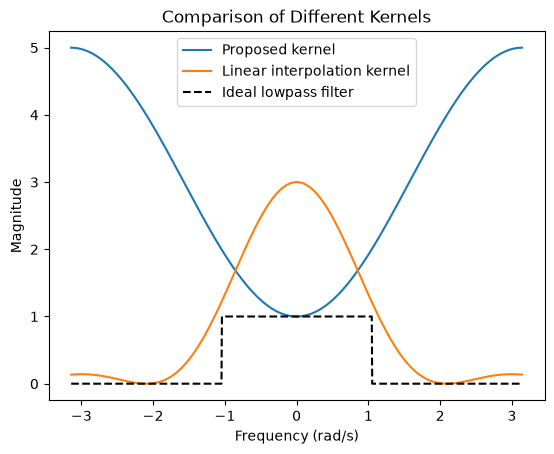

In [7]:
omega = np.linspace(-np.pi, np.pi, 1000)
G = 3 - 2 * np.cos(omega)
I = 3
G_lin = 1/I * (np.sin(omega*I/2) / (omega/2))**2
G_ideal = np.where(np.abs(omega) <= np.pi/3, 1, 0)
plt.plot(omega, G, label='Proposed kernel')
plt.plot(omega, G_lin, label='Linear interpolation kernel')
plt.plot(omega, G_ideal, label='Ideal lowpass filter', linestyle='--', color='black')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude')
plt.title('Comparison of Different Kernels')
plt.legend()
plt.show()

It can be seen that the proposed kernel is not a low-pass filter and therefore has nowhere near the same properties as the ideal kernel. Unlike the linear kernel that approximates the ideal kernel, the proposed kernel will therefore not have great performance in terms of interpolation.

# Problem 4
The file `SampleRateData.dat` contains a short segment of a signal that is sampled at 1 kHz. The signal, denoted by $x[n]$, can be loaded into `MATLAB` with `x=load('SampleRateData.dat')`. In this problem we will first form the signal $y[n]$ by decimating $x[n]$ by two. Afterwards, we create the signal $z[n]$ by 'undoing' the decimation, i.e., $z[n]$ is found by interpolating $y[n]$ by two.

## 1. Perform the decimation and interpolation. Document the procedure, plot the signals at each stage, and explain the shape of the signals after decimation and after interpolation.

The signal first has to be loaded into python. This is done with the `np.loadtxt` function.

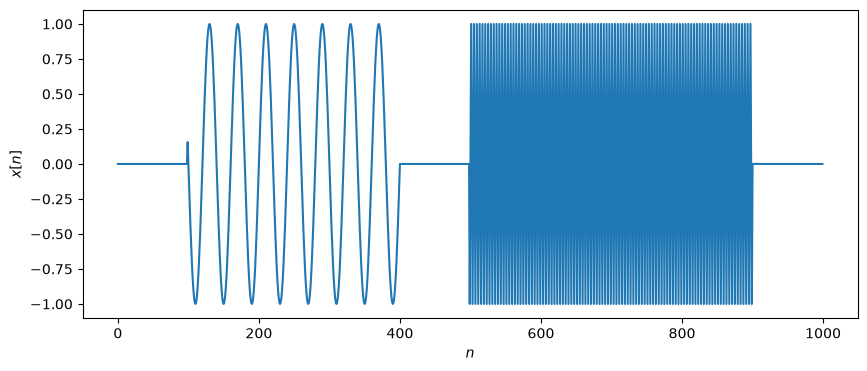

In [8]:
x = np.loadtxt("SampleRateData.dat")
n = np.arange(len(x))
plt.figure(figsize=(10, 4))
plt.xlabel("$n$")
plt.ylabel("$x[n]$")
plt.plot(n, x)

The signal be be seen to consist of a low frequency part and a high frequency part. To decimate it another python function, `scipy.signal.decimate`, can be used. This will apply a FIR filter to the signal before downsampling to avoid aliasing.

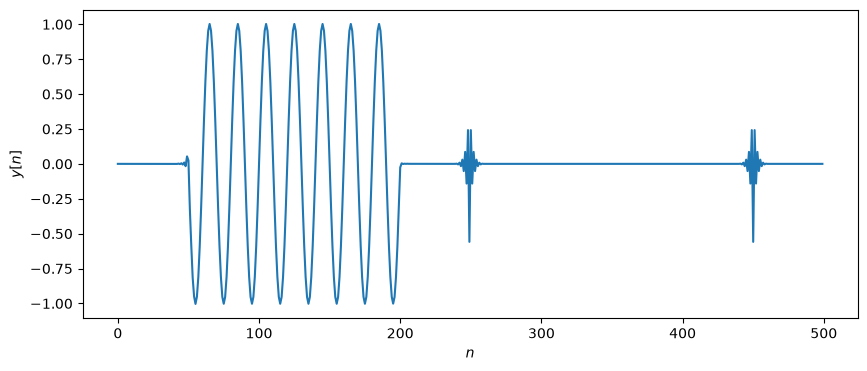

In [9]:
D = 2
y = signal.decimate(x, D, ftype='fir')
n_y = np.arange(len(y))
plt.figure(figsize=(10, 4))
plt.xlabel("$n$")
plt.ylabel("$y[n]$")
plt.plot(n_y, y)

After decimation it can be seen that the high frequency information has been greatly decreased. This is likely due to the anti-aliasing filter, which is just a lowpass filter. The low frequency is therefore untouched but the high frequency is attenuated. The signal can then be interpolated back by a factor of 2 using the `scipy.signal.resample_poly` function. This will first upsample the signal by adding zeros every 2 samples and then apply a FIR filter to removes spectral images.

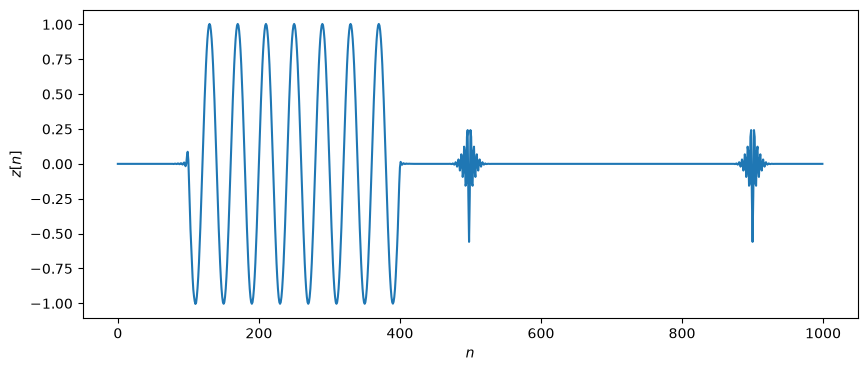

In [10]:
I = 2
z = signal.resample_poly(y, I, 1)
plt.figure(figsize=(10, 4))
plt.xlabel("$n$")
plt.ylabel("$z[n]$")
plt.plot(n, z)

The signal is back to the original samplerate, but the high frequency information is still attenuated, which is to be expected since interpolation will not be able to recover lost data.

# Problem 5
Consider a two-channel filter bank where it is intended to operate it as a quadrature mirror
filter with $H(z) = 1 + \frac{1}{2} z^{−1}$.

## 1. Are $H_0(z)$ and $H_1(z)$ power complementary?

The two filter are power complementary if they satisfy equation (12.146):
$$
|H_0(e^{j\omega})|^2 + |H_1(e^{j\omega})|^2 = 1
$$

To check this the DTFT of the original filter is needed. That is obtained by substituting $z = e^{j\omega}$ in the system function:
$$
H(e^{j\omega}) = 1 + \frac{1}{2} e^{-j\omega} = 1 + \frac{1}{2}\cos(\omega) - j\frac{1}{2}\sin(\omega)
$$

The filters are defined as $H_0(e^{j\omega}) = H(e^{j\omega})$ and $H_1(e^{j\omega}) = H(e^{j(\omega - \pi)})$. Using this knowledge the power gain of each filter can be computed as follows:
\begin{align*}
|H_0(e^{j\omega})|^{2}&= |1 + \frac{1}{2}\cos(\omega) - j\frac{1}{2}\sin(\omega)|^{2}\\
&= \sqrt{ \left( 1 + \frac{1}{2}\cos(\omega) \right)^{2} + \left( -\frac{1}{2}\sin(\omega) \right)^{2} }^{2}\\
&= 1 + \frac{1}{2}\cos(\omega) + \frac{1}{2}\cos(\omega) + \frac{1}{4}\cos ^{2}(\omega) + \frac{1}{4}\sin ^{2}(\omega)\\
&= 1 + \cos(\omega) + \frac{1}{4} (\cos ^{2}(\omega) + \sin ^{2}(\omega))\\
&= \frac{5}{4} + \cos(\omega)
\end{align*}

\begin{align*}
|H_1(e^{j\omega})|^{2}&= |1 + \frac{1}{2}\cos(\omega-\pi) - j\frac{1}{2}\sin(\omega-\pi)|^{2}\\
&= |1 - \frac{1}{2}\cos(\omega) + j\frac{1}{2}\sin(\omega)|^{2}\\
&= \sqrt{ \left( 1 - \frac{1}{2}\cos(\omega) \right)^{2} + \left(\frac{1}{2}\sin(\omega) \right)^{2} }^{2}\\
&= 1 - \frac{1}{2}\cos(\omega) - \frac{1}{2}\cos(\omega) + \frac{1}{4}\cos ^{2}(\omega) + \frac{1}{4}\sin ^{2}(\omega)\\
&= 1 - \cos(\omega) + \frac{1}{4} (\cos ^{2}(\omega) + \sin ^{2}(\omega))\\
&= \frac{5}{4} - \cos(\omega)
\end{align*}

Adding them together yields
$$
|H_0(e^{j\omega})|^{2} + |H_1(e^{j\omega})|^{2} = \frac{5}{4} + \cos(\omega) + \frac{5}{4} - \cos(\omega) = \frac{5}{2} \neq 1
$$

$H_0(z)$ and $H_1(z)$ are therefore not power complementary.

## 2. Will the choice of $H(z)$ lead to an aliasing-free filter bank?

QMF banks are inherently aliasing-free following equation (12.138), where $A(z) = 0$. This is because $A(z)$ is calculated as
$$
A(z) = H(-z)H(z) - H(z)H(-z)
$$

and since multiplication is commutative
$$
A(z) = H(-z)H(z) - H(-z)H(z) = 0
$$

## 3. Discuss the choice of $H(z)$ for a quadrature mirror filter bank.

Looking only at perfect reconstruction, the choice of $H(z)$ is not terrible. It is automatically aliasing-free and if the magnitude and phase distortion is analyzed it can be shown that the filter has a pure delay and satisfies the perfect reconstruction criteria. This can be found using equation (12.139) and (12.141) as follows:
\begin{align*}
T(z) &= H^{2}(z) - H^{2}(-z)\\
&= \left( 1 + \frac{1}{2} z^{−1} \right)^{2} - \left( 1 + \frac{1}{2} (-z)^{−1} \right)^{2}\\
&= 1 + z^{-1} + \frac{1}{4}z^{-2} - \left( 1 - z^{-1} + \frac{1}{4}z^{-2} \right)\\
&= 2z^{-1}
\end{align*}

\begin{align*}
T(z) &= 2z^{-1}P_{0}(z^{2})P_{1}(z^{2})\\
2z^{-1} &= 2z^{-1}P_{0}(z^{2})P_{1}(z^{2})\\
P_{0}(z^{2})P_{1}(z^{2}) &= 1
\end{align*}

Since the product of the two polynomials is 1, there is a delay of 0 samples which is a pure delay, meaning that perfect reconstruction with the choice of $H(z)$ is possible in all other aspects than the power complementary criertia. It could be said that since the power sum has a constant value of $\frac{5}{2}$, the only distortion is a uniform power gain of $\frac{5}{2}$, which is not the worst distortion to have since it can be scaled back down to 1. Purely looking at in and output, $H(z)$ is not terrible.

Where $H(z)$ fails can be seen in the frequency response. As seen below it's characteristics are far from the ideal low-pass filter that is desired for a QMF bank. The magnitude response is firstly not flat in the passband, which could arguably be desired for some applications, but it is also not zero in the stopband. This means that the filter cannot separate the low and high frequencies without having spectral leakage. What does not help is also the width of the transition band. If the signal is processed at all after having passed through the analysis filter bank, the output signal almost certainly not be reconstructed perfectly. The choice of $H(z)$ is therefore not a good choice for a QMF bank if the goal is to actually separate the low and high frequencies.

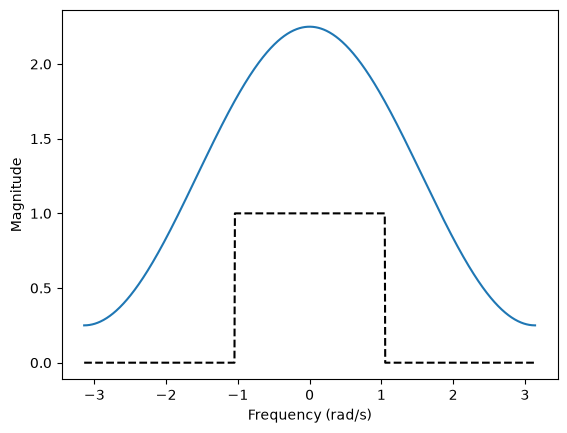

In [11]:
omega = np.linspace(-np.pi, np.pi, 1000)
H = 5/4 + np.cos(omega)
H_ideal = np.where(np.abs(omega) <= np.pi/3, 1, 0)
plt.plot(omega, H)
plt.plot(omega, H_ideal, label='Ideal lowpass filter', linestyle='--', color='black')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude')
plt.show()

# Problem 6
The file `dataset.dat` contains 2048 samples of an unknown signal. The signal can be loaded
into `MATLAB` with `x=load('dataset.dat')`.

## 1. Compute and plot the autocorrelation for an appropriate range of lags. Compare it with the autocorrelation for an equal length realization of white Gaussion noise with the same power. What can be derived about the signal in the file from the autocorrelation? 

The autocorrelations are computed using the `scipy.signal.correlate` function. To obtain a white Gaussian noise with the same power, the Gaussian noise is generated using the `np.random.normal` function with a mean of 0 and a standard deviation of $\sigma = \sqrt{E[x^2]}$. This ensures that the variance of the Gaussian noise is $\sigma^2 = \sqrt{E[x^2]}^2 = E[x^2]$, corresponding to the mean power of the signal.

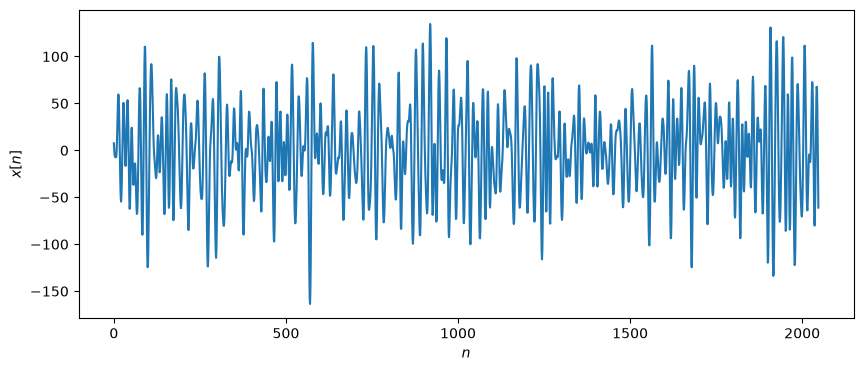

In [12]:
x = np.loadtxt("dataset.dat")
n = np.arange(len(x))
plt.figure(figsize=(10, 4))
plt.xlabel("$n$")
plt.ylabel("$x[n]$")
plt.plot(n, x)

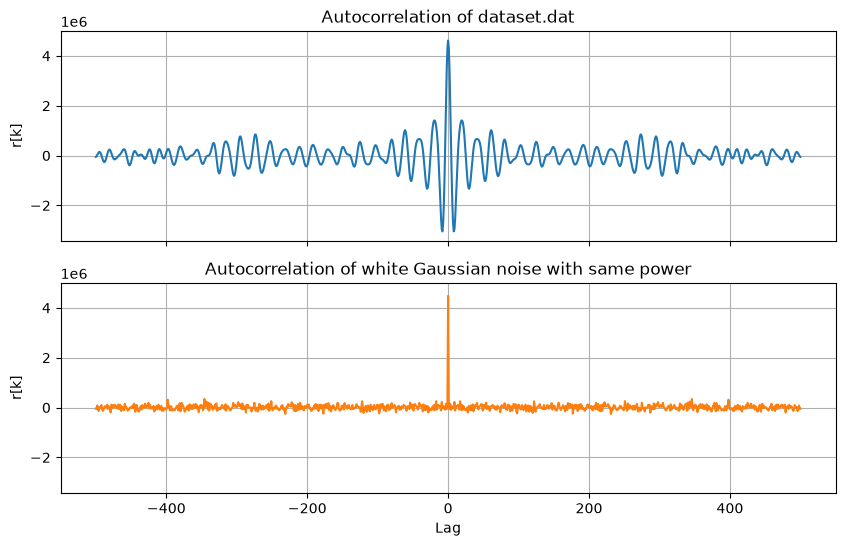

In [13]:
max_lag = 500
r_xx = signal.correlate(x, x, mode='full')[len(x)-1-max_lag:len(x)+max_lag]
lags = np.arange(-max_lag, max_lag+1, 1)

w = np.random.normal(0, np.sqrt(np.mean(x**2)), len(x))
r_ww = np.correlate(w, w, mode='full')[len(w)-1-max_lag:len(w)+max_lag]

plt.subplots(2, 1, figsize=(10, 6), sharex=True, sharey=True)
plt.subplot(2, 1, 1)
plt.plot(lags, r_xx)
plt.title('Autocorrelation of dataset.dat')
plt.ylabel('r[k]')
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(lags, r_ww, color='tab:orange')
plt.title('Autocorrelation of white Gaussian noise with same power')
plt.xlabel('Lag')
plt.ylabel('r[k]')
plt.grid()
plt.show()

When looking at the two autocorrelations, it can be seen that the signal from the dataset is somewhat periodic, since there are peaks and troughs throughout unlike the Gaussian noise which only peaks at 0 lag. It is also seen that the signal is most correlated with itself near 0 lag, which is expected, but then it increases again with a lobe at around a 300 sample lag. This could mean that it has periodicity over longer segments like a song with a repeating pattern.

## 2. Estimate and plot the power spectral density of the signal using first a periodogram and second Welch's method. Discuss the results and explain the pros and cons of the two methods.

This is done by using the `scipy.signal.periodogram` and `scipy.signal.welch` functions. Since no frequency is given the default value of 1.0 is used. Welch's method is done with an overlap of 50% since it reduces the variance by about a factor of two and higher overlap will not reduce the variance any further. Different length of segments ($L$) are used to see how it affects the PSD plot.

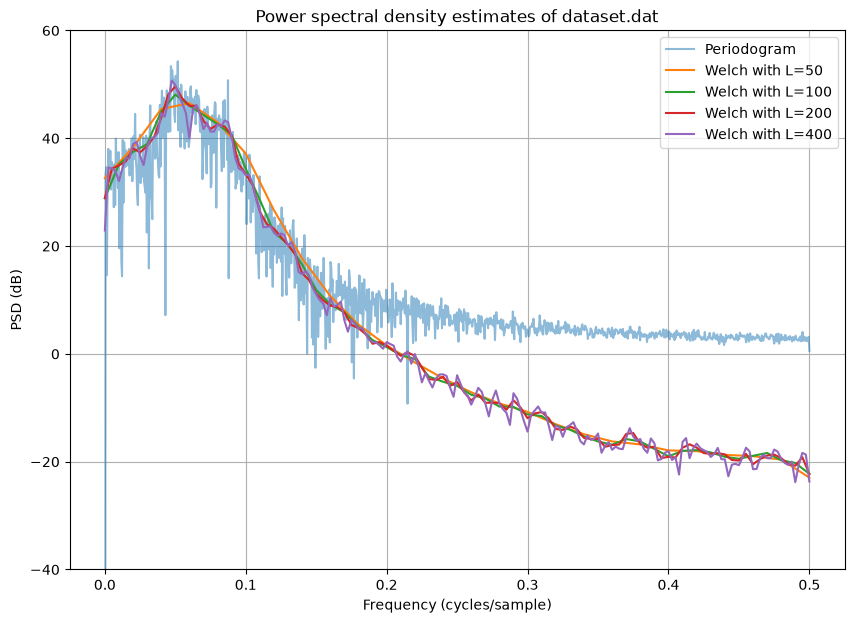

In [14]:
frequencies_pg, psd_pg = signal.periodogram(x)
plt.subplots(figsize=(10, 7))
plt.plot(frequencies_pg, 10 * np.log10(psd_pg), label='Periodogram', alpha=0.5)

L_values = [50, 100, 200, 400]
for L in L_values:
    frequencies, psd = signal.welch(x, nperseg=L, noverlap=L//2)
    plt.plot(frequencies, 10 * np.log10(psd), label=f'Welch with L={L}')

plt.title('Power spectral density estimates of dataset.dat')
plt.xlabel('Frequency (cycles/sample)')
plt.ylabel('PSD (dB)')
plt.ylim([-40, 60])
plt.legend()
plt.grid()

One of the big changes between the two methods is that the periodogram flattens out at a higher PSD value than Welch's method in the higher frequency range. This happens because strong narrowband components in the lower frequencies can leak into the higher frequencies increasing the power floor. The Welch method reduces this effect by using windowing to lowering the level of sidelobes. 

It can also be seen that lowering the segment length in Welch's decreases the variance and smoothens out the plot but also reduces the resolution and vice versa for increasing the segments length. Almost no detail can be read from the periodogram because it is too noisy, but similarly no information can be read from the Welch method with $L=50$ since all the information is smoothed out and lost. The best middleground is found to be $L=200$ in this case. With this segment length, the resolution is good enough that two peaks can be seen in the beginning of the plot and the variance is low enough that it seems to follow a trend without derailing as much as the plot with $L=400$.